# ResNet18 Benchmark

In [1]:
import torch
from torch import nn
from torchvision import models
import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

from collections import namedtuple
from timeit import timeit
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## 准备

将模型编译为 TOSA IR

In [2]:
resnet18 = models.resnet18(pretrained=False).train(False)
resnet18.load_state_dict({k: torch.ones_like(v) * 114514e-5 for k, v in resnet18.state_dict().items()})

# with open("resnet18.mlir", "w") as f:
#     f.write(
#         str(torch_mlir.compile(resnet18, torch.ones(1, 3, 224, 224), output_type="tosa"))
#     )

/home/ccy/miniconda3/envs/iree/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ccy/miniconda3/envs/iree/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

## 编译

将不同策略生成的反向 IR 编译为 VM Modules

In [3]:
def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def mytimeit(stmt, n=100):
    return timeit(stmt, globals=globals(), number=n) * 1000 / n

recompute, checkpoint, storeall = [compile_file(x) for x in ["recompute.mlir", "checkpoint.mlir", "storeall.mlir"]]

/home/ccy/miniconda3/envs/iree/lib/python3.10/site-packages/iree/runtime/system_api.py:305: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vm_module = _binding.VmModule.from_flatbuffer(config.vm_instance, vm_flatbuffer)


## 实验

### 数据准备

In [4]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = resnet18(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

### PyTorch (Baseline)

In [5]:
f = mytimeit("resnet18(image)")
b = mytimeit("torch.autograd.grad(output, [image], grad, retain_graph=True)")
torch_df = get_dataframe(f, b, "PyTorch")

### Nabla Recompute-All

In [6]:
f = mytimeit("recompute.forward(image_np)")
b = mytimeit("recompute.dforward(grad_np)")
recompute_df = get_dataframe(f, b, "Nabla Recompute-All")

### Nabla Store-All

In [7]:
f = mytimeit("storeall.forward(image_np)")
b = mytimeit("storeall.dforward(grad_np)")
storeall_df = get_dataframe(f, b, "Nabla Store-All")

### Nabla Checkpoint

In [8]:
f = mytimeit("checkpoint.forward(image_np)")
b = mytimeit("checkpoint.dforward(grad_np)")
checkpoint_df = get_dataframe(f, b, "Nabla Checkpoint")

## 结果

In [9]:
df = pd.concat([torch_df, recompute_df, storeall_df, checkpoint_df])
df.style.hide(axis="index")

time,pass,item
21.752618,Forward,PyTorch
21.952687,Backward,PyTorch
43.705305,Full,PyTorch
12.006415,Forward,Nabla Recompute-All
44.662011,Backward,Nabla Recompute-All
56.668425,Full,Nabla Recompute-All
18.512315,Forward,Nabla Store-All
28.899927,Backward,Nabla Store-All
47.412242,Full,Nabla Store-All
18.547245,Forward,Nabla Checkpoint


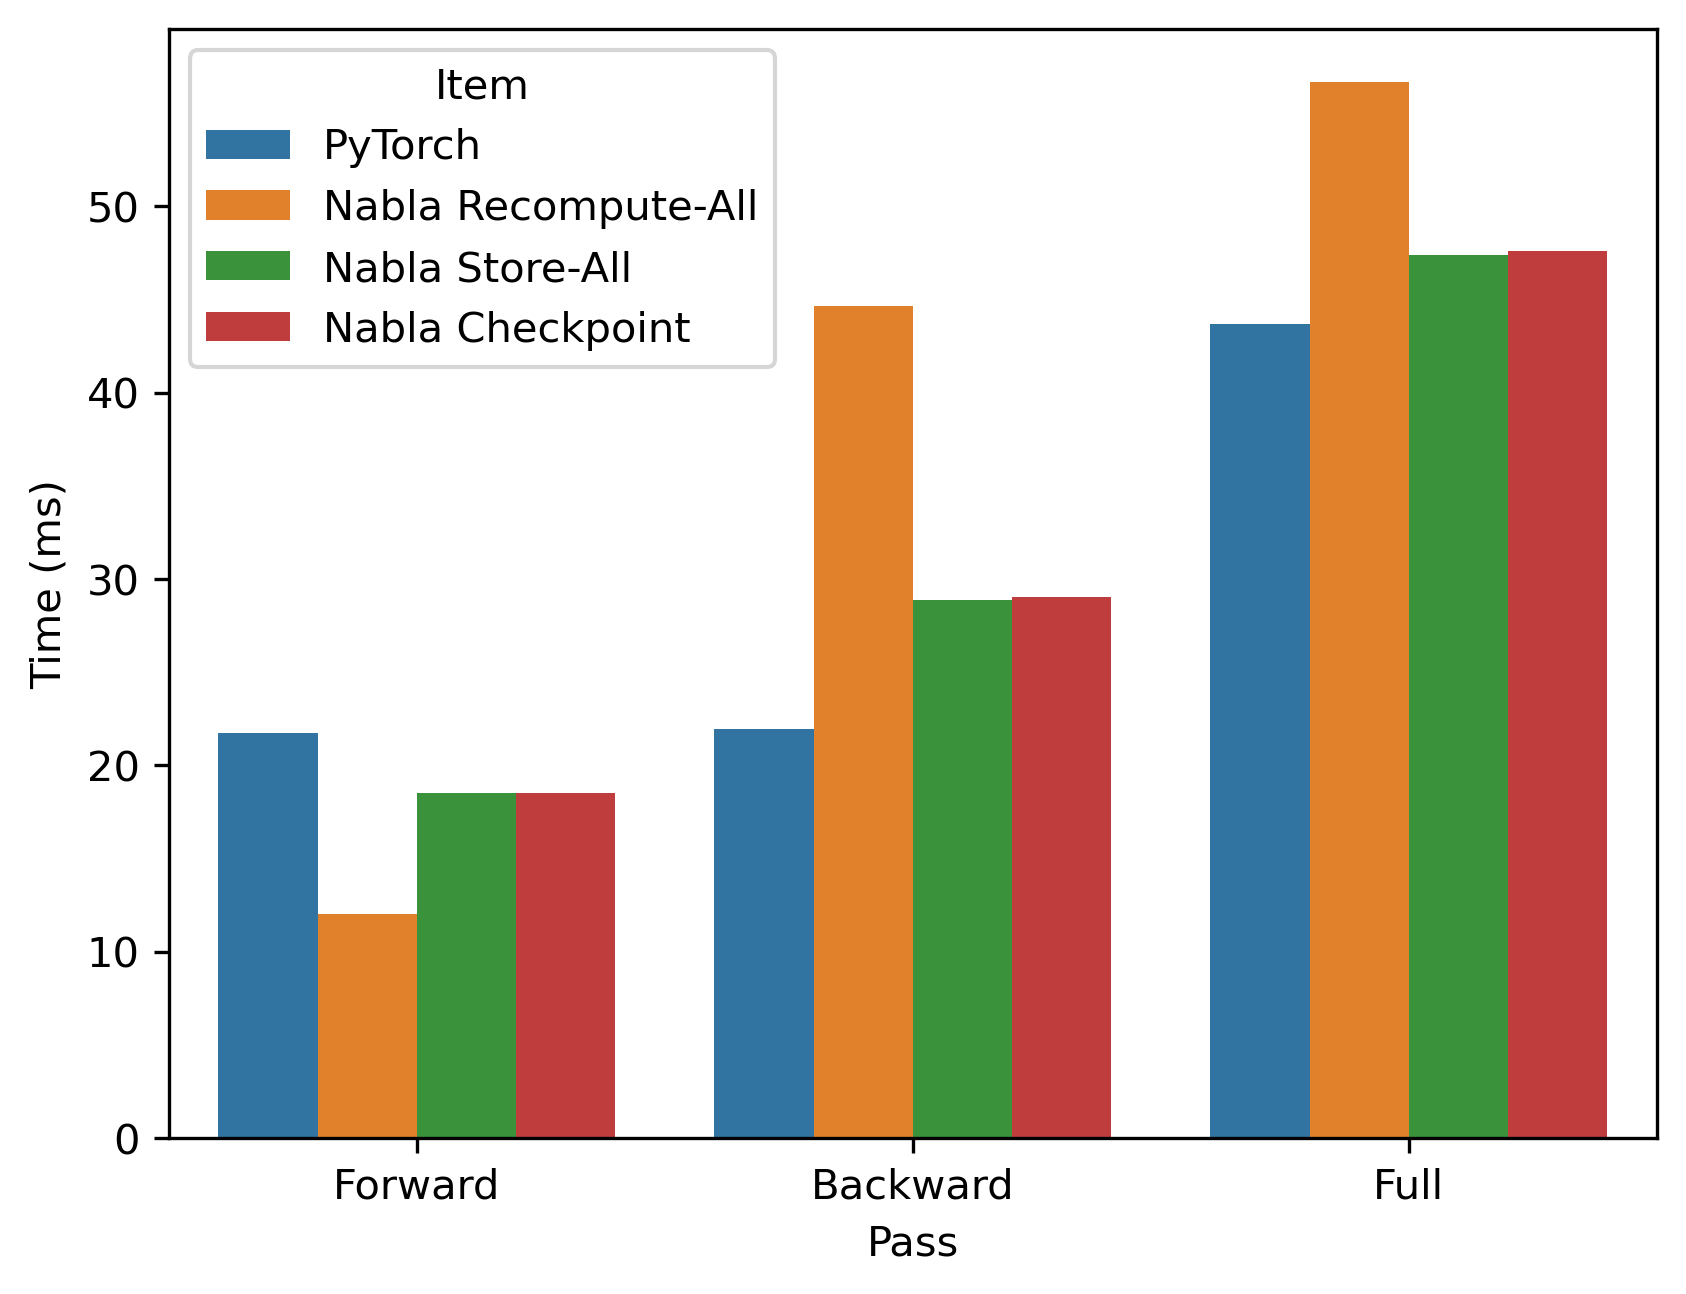

In [10]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")